# Explanation of Scales of variability 

**Purpose**: Code for showing schematically what the scales of variability means.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter1d

Construct an idealized temperature time series

In [89]:
# Set the time vector (units: days)
t = np.linspace(0, 120, 3000)

#Define the temperature time series with multiple sinusoidal components to mimic variability at different scales
temp = (
    14.0                                       # Time mean 
    + 2.8 * np.sin(2 * np.pi * t / 78)         # Dominant low-frequency mode 78
    + 0.7 * np.sin(2 * np.pi * t / 24 + 0.9)   # Higher-frequency variability
    + 0.35 * np.cos(2 * np.pi * t / 14 - 0.5)  # Weak short-scale structure
)
#temp = np.fliplr(temp.reshape(1, -1))[0]  # Flip the time series 

# Obtain two sample points from the time series using interpolation
t1, t2 = 28.0, 45.0
temp1 = np.interp(t1, t, temp)
temp2 = np.interp(t2, t, temp)

Set plotting parameters 

In [90]:
# Set plotting parameters 
fontsize = 15
blue  = "#1f5d99"
amber = "#b36a1e"
gray  = "#666666"

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 
#plt.rcParams['path.sketch'] = (1, 150, 2)

# Set path to save figures
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/'

Plot the temperature and scale of variablilty 

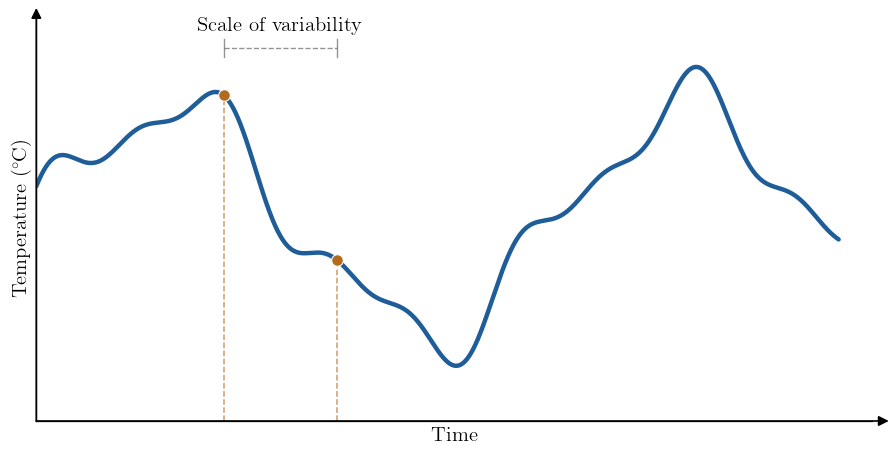

In [93]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(9.2, 4.8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Main temperature curve
ax.plot(
    t,
    temp,
    color=blue,
    linewidth=3.2,
    solid_capstyle="round",
    zorder=3,
)

# Sample points
ax.scatter(
    [t1, t2],
    [temp1, temp2],
    s=70,
    color=amber,
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
)

# Vertical guides
for tx, Ty in [(t1, temp1), (t2, temp2)]:
    ax.plot(
        [tx, tx],
        [9.0, Ty],
        linestyle="--",
        linewidth=1.1,
        color=amber,
        alpha=0.65,
        zorder=2,
    )

# Plot horizontal line and ticks to indicate the scale of variability
top_y = 18.3

ax.plot(
    [t1, t2],
    [top_y, top_y],
    linestyle="--",
    linewidth=1.0,
    color=gray,
    alpha=0.7,
)

tick_h = 0.22

for tx in [t1, t2]:
    ax.plot(
        [tx, tx],
        [top_y - tick_h, top_y + tick_h],
        color=gray,
        linewidth=1.0,
        alpha=0.7,
    )

ax.text(
    0.5 * (t1 + t2),
    top_y + 0.32,
    "Scale of variability",
    ha="center",
    va="bottom",
    fontsize=fontsize,
    color='k',
    style="italic",
)

# Set figure attribute
ax.set_xlabel("Time")
ax.set_ylabel(r"Temperature ($^\circ$C)")
ax.set_xlim(0, 125)
ax.set_ylim(9.0, 19.1)
# ax.set_xticks(np.arange(0, 121, 20))
# ax.set_yticks([10, 12, 14, 16, 18])
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis="both", which="major", length=4, width=0.8)
#ax.grid(linestyle='--',alpha=0.3,color='grey')

# Draw arrowed x- and y-axes
ax.annotate(
    "",
    xy=(1.02, 0),          # arrow tip
    xytext=(0, 0),         # start
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.2,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
    annotation_clip=False,
)
ax.annotate(
    "",
    xy=(0, 1.02),
    xytext=(0, 0),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.2,
        color="black",
        shrinkA=0,
        shrinkB=0,
    ),
    annotation_clip=False,
)

# Spine styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)

# Adjust layout
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'supplementary_figs/figS60.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

